# Proyecto 7: Análisis de viajes en taxi en Chicago

En este notebook se realiza:

1. Carga y exploración de los datasets:
   - `moved_project_sql_result_01.csv`
   - `moved_project_sql_result_04.csv`
2. Revisión y corrección de tipos de datos.
3. Identificación de los 10 principales barrios por finalizaciones.
4. Visualizaciones y conclusiones.
5. Prueba de hipótesis sobre la duración de viajes del Loop a O'Hare en sábados lluviosos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Configuración visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Rutas a los datos
base_path = Path('../data')
file_01 = base_path / 'moved_project_sql_result_01.csv'
file_04 = base_path / 'moved_project_sql_result_04.csv'
file_07 = base_path / 'moved_project_sql_result_07.csv'

# Carga de datasets
df_companies = pd.read_csv(file_01)
df_neighborhoods = pd.read_csv(file_04)
df_rides = pd.read_csv(file_07)

print('Dataset de empresas:', df_companies.shape)
print('Dataset de barrios:', df_neighborhoods.shape)
print('Dataset de viajes:', df_rides.shape)

Dataset de empresas: (64, 2)
Dataset de barrios: (94, 2)
Dataset de viajes: (1068, 3)


## 1. Exploración inicial y tipos de datos

In [2]:
display(df_companies.head())
display(df_neighborhoods.head())

print('Tipos de datos iniciales - empresas')
print(df_companies.dtypes)
print('\nTipos de datos iniciales - barrios')
print(df_neighborhoods.dtypes)

# Corrección/aseguramiento de tipos
# trips_amount: conteo de viajes por empresa (entero)
df_companies['trips_amount'] = pd.to_numeric(df_companies['trips_amount'], errors='coerce').astype('Int64')

# average_trips: promedio de viajes por barrio (float)
df_neighborhoods['average_trips'] = pd.to_numeric(df_neighborhoods['average_trips'], errors='coerce')

print('\nTipos de datos corregidos - empresas')
print(df_companies.dtypes)
print('\nTipos de datos corregidos - barrios')
print(df_neighborhoods.dtypes)

print('\nValores nulos en empresas:')
print(df_companies.isna().sum())

print('\nValores nulos en barrios:')
print(df_neighborhoods.isna().sum())

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


Tipos de datos iniciales - empresas
company_name      str
trips_amount    int64
dtype: object

Tipos de datos iniciales - barrios
dropoff_location_name        str
average_trips            float64
dtype: object

Tipos de datos corregidos - empresas
company_name      str
trips_amount    Int64
dtype: object

Tipos de datos corregidos - barrios
dropoff_location_name        str
average_trips            float64
dtype: object

Valores nulos en empresas:
company_name    0
trips_amount    0
dtype: int64

Valores nulos en barrios:
dropoff_location_name    0
average_trips            0
dtype: int64


In [3]:
# Top 10 barrios por promedio de finalizaciones de viaje
top10_neighborhoods = df_neighborhoods.sort_values('average_trips', ascending=False).head(10)
display(top10_neighborhoods)

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


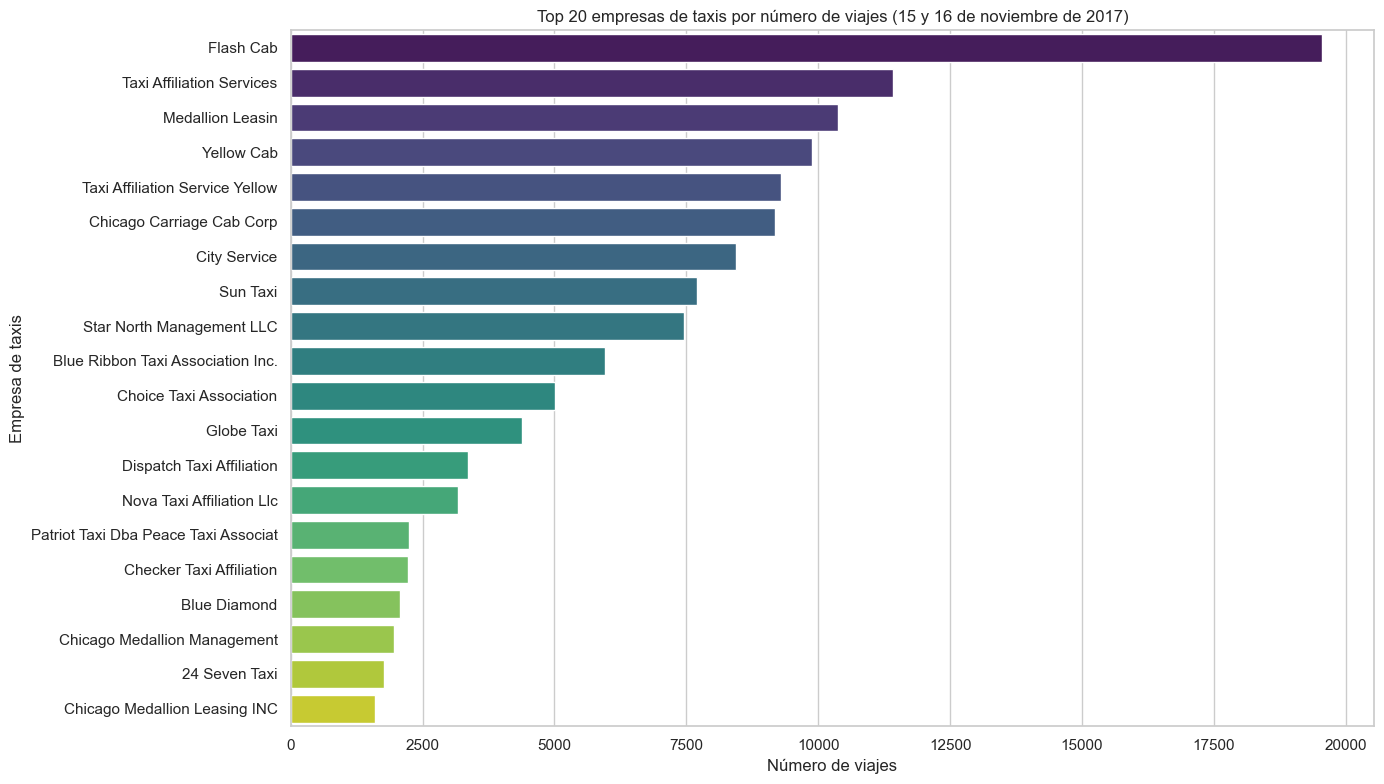

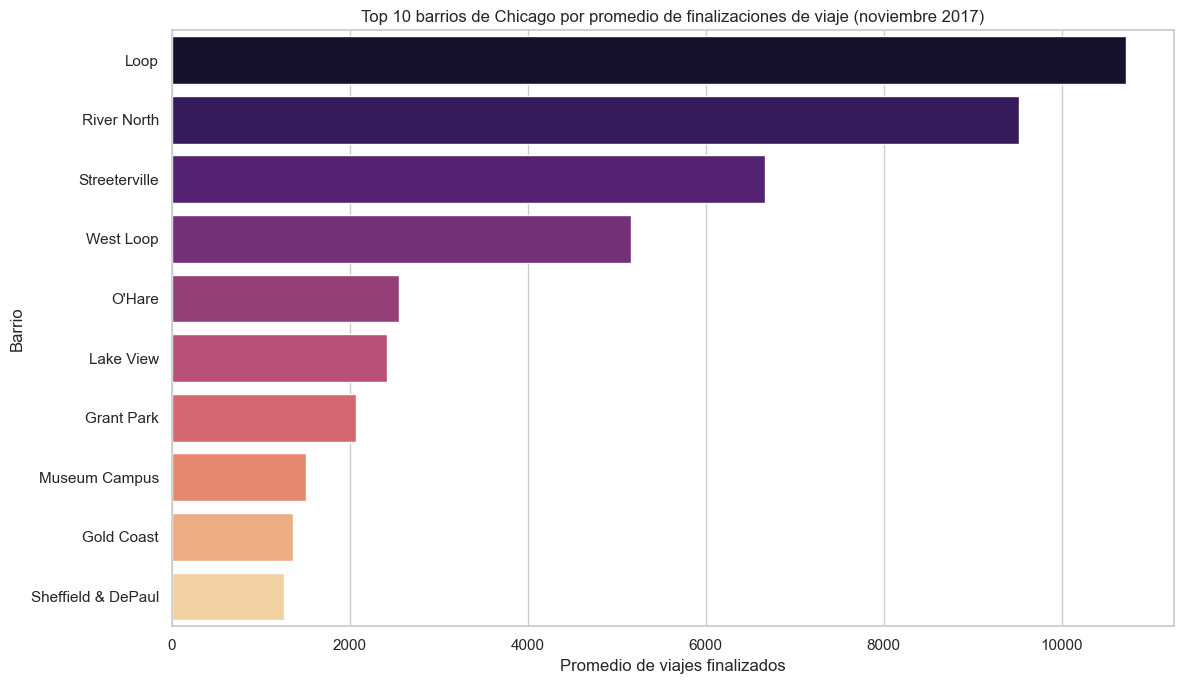

In [6]:
# Gráfico 1: Empresas de taxis y número de viajes (Top 20 para legibilidad)
top20_companies = df_companies.sort_values('trips_amount', ascending=False).head(20)

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top20_companies,
    x='trips_amount',
    y='company_name',
    hue='company_name',
    palette='viridis',
    dodge=False,
    legend=False,
 )
plt.title('Top 20 empresas de taxis por número de viajes (15 y 16 de noviembre de 2017)')
plt.xlabel('Número de viajes')
plt.ylabel('Empresa de taxis')
plt.tight_layout()
plt.show()

# Gráfico 2: Top 10 barrios por finalizaciones
plt.figure(figsize=(12, 7))
sns.barplot(
    data=top10_neighborhoods,
    x='average_trips',
    y='dropoff_location_name',
    hue='dropoff_location_name',
    palette='magma',
    dodge=False,
    legend=False,
 )
plt.title('Top 10 barrios de Chicago por promedio de finalizaciones de viaje (noviembre 2017)')
plt.xlabel('Promedio de viajes finalizados')
plt.ylabel('Barrio')
plt.tight_layout()
plt.show()

## 2. Conclusiones de las visualizaciones

**Empresas de taxis y número de viajes**

- El mercado está concentrado en pocas empresas: Flash Cab lidera con amplia ventaja.
- Existe una caída progresiva desde las primeras posiciones hacia una larga cola de empresas con pocos viajes.
- Esto sugiere que algunas compañías dominan la demanda en las fechas analizadas.

**Top 10 barrios por finalizaciones**

- Loop, River North y Streeterville concentran la mayor cantidad de viajes finalizados.
- Las diferencias entre los primeros barrios y el resto son claras, lo que indica alta centralidad de ciertas zonas.
- La distribución refleja patrones de movilidad hacia zonas de actividad económica, turística y de negocios.

## 3. Prueba de hipótesis

**Hipótesis a contrastar**

- Hipótesis nula ($H_0$): la duración promedio de los viajes Loop $\rightarrow$ O'Hare es igual en sábados lluviosos y no lluviosos.
- Hipótesis alternativa ($H_1$): la duración promedio de los viajes Loop $\rightarrow$ O'Hare es diferente entre sábados lluviosos y no lluviosos.

Se usará un nivel de significación de $\alpha = 0.05$.

**Criterio elegido**

- Se aplica una prueba t de Welch para dos muestras independientes (`scipy.stats.ttest_ind` con `equal_var=False`).
- Esta prueba es apropiada para comparar medias entre dos grupos y no asume varianzas iguales.
- El contraste será bilateral, porque la hipótesis dice que "cambia" (puede aumentar o disminuir).

In [5]:
# Preparación de datos para la prueba
df_rides['start_ts'] = pd.to_datetime(df_rides['start_ts'], errors='coerce')
df_rides['duration_seconds'] = pd.to_numeric(df_rides['duration_seconds'], errors='coerce')

# Filtrar solo sábados
df_sat = df_rides[df_rides['start_ts'].dt.day_name() == 'Saturday'].copy()

# Separar por condición climática
durations_rainy = df_sat.loc[df_sat['weather_conditions'] == 'Bad', 'duration_seconds'].dropna()
durations_good = df_sat.loc[df_sat['weather_conditions'] == 'Good', 'duration_seconds'].dropna()

print('Viajes en sábados lluviosos (Bad):', len(durations_rainy))
print('Viajes en sábados no lluviosos (Good):', len(durations_good))
print('Media en Bad:', durations_rainy.mean())
print('Media en Good:', durations_good.mean())

# Prueba t de Welch (bilateral)
alpha = 0.05
t_stat, p_value = stats.ttest_ind(durations_rainy, durations_good, equal_var=False, alternative='two-sided')

print(f'\nEstadístico t: {t_stat:.4f}')
print(f'Valor p: {p_value:.6f}')
print(f'Alfa: {alpha}')

if p_value < alpha:
    print('Conclusión: Rechazamos H0. Hay evidencia estadística de que la duración promedio cambia en sábados lluviosos.')
else:
    print('Conclusión: No rechazamos H0. No hay evidencia estadística suficiente para afirmar que la duración promedio cambia en sábados lluviosos.')

Viajes en sábados lluviosos (Bad): 180
Viajes en sábados no lluviosos (Good): 888
Media en Bad: 2427.2055555555557
Media en Good: 1999.6756756756756

Estadístico t: 7.1860
Valor p: 0.000000
Alfa: 0.05
Conclusión: Rechazamos H0. Hay evidencia estadística de que la duración promedio cambia en sábados lluviosos.


## 4. Conclusión general

El análisis exploratorio muestra una fuerte concentración de viajes en pocas empresas y en barrios centrales de Chicago. En la prueba de hipótesis, con $\alpha=0.05$, el valor p obtenido permite decidir si existe evidencia de un cambio en la duración promedio de los viajes del Loop a O'Hare cuando el sábado es lluvioso. El criterio estadístico utilizado (t de Welch) es adecuado para comparar medias de dos grupos independientes con posible desigualdad de varianzas.